In [1]:


import numpy as np 
import pandas as pd 



import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



In [2]:
import pandas as pd
import numpy as np
import ast
import pickle

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

In [3]:
movies = pd.read_csv("movies_metadata.csv", low_memory=False)
credits = pd.read_csv("credits.csv")
keywords = pd.read_csv("keywords.csv")
ratings = pd.read_csv("ratings.csv")
links = pd.read_csv("links.csv")

# Keep full movies for collaborative filtering title lookup
movies_full = movies.copy()

In [4]:
movies.head(2)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0


In [5]:
movies.shape

(45466, 24)

In [6]:
credits.head()

,cast,crew,id
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",862
1,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",8844
2,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...",15602
3,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...",31357
4,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...",11862


In [7]:
movies['id'] = pd.to_numeric(movies['id'], errors='coerce')
movies = movies.dropna(subset=['id'])
movies['id'] = movies['id'].astype(int)

# Create movieId to title mapping for collaborative filtering
movieId_to_title = {}
for _, row in links.iterrows():
    movieId = row['movieId']
    tmdbId = row['tmdbId']
    if pd.notna(movieId) and pd.notna(tmdbId):
        movie_row = movies_full[movies_full['id'] == int(tmdbId)]
        if not movie_row.empty:
            title = movie_row['title'].values[0]
            movieId_to_title[int(movieId)] = title

In [8]:
print(movies.columns)
print(credits.columns)
print(keywords.columns)

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')
Index(['cast', 'crew', 'id'], dtype='object')
Index(['id', 'keywords'], dtype='object')


In [9]:
movies = movies.merge(credits, on='id')
movies = movies.merge(keywords, on='id')

In [10]:
print(movies.columns)

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count', 'cast', 'crew', 'keywords'],
      dtype='object')


In [11]:

movies = movies.head(10000)
movies.reset_index(drop=True, inplace=True)

In [12]:
movies.head()
# budget
# homepage
# id
# original_language
# original_title
# popularity
# production_comapny
# production_countries
# release-date(not sure)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,spoken_languages,status,tagline,title,video,vote_average,vote_count,cast,crew,keywords
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...","[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...","[{'id': 10090, 'name': 'board game'}, {'id': 1..."
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...","[{'id': 1495, 'name': 'fishing'}, {'id': 12392..."
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...","[{'id': 818, 'name': 'based on novel'}, {'id':..."
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...","[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n..."


In [13]:
movies['overview'] = movies['overview'].fillna('')

In [14]:
movies = movies[['id','title','overview','genres','keywords','cast','crew']]

In [15]:
movies.head()

,id,title,overview,genres,keywords,cast,crew
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[{'id': 16, 'name': 'Animation'}, {'id': 35, '...","[{'id': 931, 'name': 'jealousy'}, {'id': 4290,...","[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de..."
1,8844,Jumanji,When siblings Judy and Peter discover an encha...,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...","[{'id': 10090, 'name': 'board game'}, {'id': 1...","[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de..."
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...","[{'id': 1495, 'name': 'fishing'}, {'id': 12392...","[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de..."
3,31357,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...","[{'id': 818, 'name': 'based on novel'}, {'id':...","[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de..."
4,11862,Father of the Bride Part II,Just when George Banks has recovered from his ...,"[{'id': 35, 'name': 'Comedy'}]","[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n...","[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de..."


In [16]:
import ast

In [17]:
def convert(text):
    L = []
    
    # If already list → return directly
    if isinstance(text, list):
        return text
    
    # If string → convert
    try:
        for i in ast.literal_eval(text):
            L.append(i['name'])
    except:
        return []
    
    return L


movies['genres'] = movies['genres'].apply(convert)
movies['keywords'] = movies['keywords'].apply(convert)
movies['cast'] = movies['cast'].apply(convert)

In [18]:
movies['keywords'] = movies['keywords'].apply(convert)
movies.head()

,id,title,overview,genres,keywords,cast,crew
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[Animation, Comedy, Family]","[jealousy, toy, boy, friendship, friends, riva...","[Tom Hanks, Tim Allen, Don Rickles, Jim Varney...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de..."
1,8844,Jumanji,When siblings Judy and Peter discover an encha...,"[Adventure, Fantasy, Family]","[board game, disappearance, based on children'...","[Robin Williams, Jonathan Hyde, Kirsten Dunst,...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de..."
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[Romance, Comedy]","[fishing, best friend, duringcreditsstinger, o...","[Walter Matthau, Jack Lemmon, Ann-Margret, Sop...","[{'credit_id': '52fe466a9251416c75077a89', 'de..."
3,31357,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[Comedy, Drama, Romance]","[based on novel, interracial relationship, sin...","[Whitney Houston, Angela Bassett, Loretta Devi...","[{'credit_id': '52fe44779251416c91011acb', 'de..."
4,11862,Father of the Bride Part II,Just when George Banks has recovered from his ...,[Comedy],"[baby, midlife crisis, confidence, aging, daug...","[Steve Martin, Diane Keaton, Martin Short, Kim...","[{'credit_id': '52fe44959251416c75039ed7', 'de..."


In [19]:
import ast
ast.literal_eval('[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]')

[{'id': 28, 'name': 'Action'},
 {'id': 12, 'name': 'Adventure'},
 {'id': 14, 'name': 'Fantasy'},
 {'id': 878, 'name': 'Science Fiction'}]

In [20]:
def convert_cast(text):
    
    if isinstance(text, list):
        return text[:3]

    L = []
    counter = 0

    for i in ast.literal_eval(text):
        if counter < 3:
            L.append(i['name'])
            counter += 1

    return L

In [21]:
movies['cast'] = movies['cast'].apply(convert_cast)

In [22]:
def fetch_director(text):
    L = []
    
    # If already list
    if isinstance(text, list):
        for i in text:
            # handle both dict and string cases
            if isinstance(i, dict):
                if i.get('job') == 'Director':
                    L.append(i.get('name'))
            else:
                L.append(i)
        return L
    
    # If string → convert
    try:
        for i in ast.literal_eval(text):
            if i['job'] == 'Director':
                L.append(i['name'])
    except:
        return []
    
    return L



In [23]:
movies['crew'] = movies['crew'].apply(fetch_director)

In [24]:
#movies['overview'] = movies['overview'].apply(lambda x:x.split())
movies.sample(5)

,id,title,overview,genres,keywords,cast,crew
5743,47888,Rollover,An Arab oil organization devises a plan to wre...,"[Drama, Mystery, Romance, Thriller]","[oil, arab]","[Jane Fonda, Kris Kristofferson, Hume Cronyn]",[Alan J. Pakula]
8731,41471,Lone Wolf and Cub: Sword of Vengeance,In this first film of the Lone Wolf and Cub se...,"[Drama, Action]","[japan, assassin, samurai]","[Tomisaburō Wakayama, Fumio Watanabe, Shigeru ...",[Kenji Misumi]
1981,9325,The Jungle Book,The boy Mowgli makes his way to the man-villag...,"[Family, Animation, Adventure]","[indian lead, narration, human animal relation...","[Bruce Reitherman, Phil Harris, Sebastian Cabot]",[Wolfgang Reitherman]
3711,11830,Tampopo,A pair of truck drivers happen onto a decrepit...,[Comedy],"[widow, food, truck driver, hoodlum, noodle]","[Tsutomu Yamazaki, Nobuko Miyamoto, Ken Watanabe]",[Juzo Itami]
2285,37536,Ringmaster,"Jerry Springer stars as more or less himself, ...",[Comedy],"[talk show, raunchy]","[Jerry Springer, Jaime Pressly, Molly Hagan]",[Neil Abramson]


In [25]:
def collapse(L):
    L1 = []
    for i in L:
        L1.append(i.replace(" ",""))
    return L1

In [26]:
movies['cast'] = movies['cast'].apply(collapse)
movies['crew'] = movies['crew'].apply(collapse)
movies['genres'] = movies['genres'].apply(collapse)
movies['keywords'] = movies['keywords'].apply(collapse)

In [27]:
movies.head()

,id,title,overview,genres,keywords,cast,crew
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[Animation, Comedy, Family]","[jealousy, toy, boy, friendship, friends, riva...","[TomHanks, TimAllen, DonRickles]",[JohnLasseter]
1,8844,Jumanji,When siblings Judy and Peter discover an encha...,"[Adventure, Fantasy, Family]","[boardgame, disappearance, basedonchildren'sbo...","[RobinWilliams, JonathanHyde, KirstenDunst]",[JoeJohnston]
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[Romance, Comedy]","[fishing, bestfriend, duringcreditsstinger, ol...","[WalterMatthau, JackLemmon, Ann-Margret]",[HowardDeutch]
3,31357,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[Comedy, Drama, Romance]","[basedonnovel, interracialrelationship, single...","[WhitneyHouston, AngelaBassett, LorettaDevine]",[ForestWhitaker]
4,11862,Father of the Bride Part II,Just when George Banks has recovered from his ...,[Comedy],"[baby, midlifecrisis, confidence, aging, daugh...","[SteveMartin, DianeKeaton, MartinShort]",[CharlesShyer]


In [28]:
movies['genres'] = movies['genres'].apply(lambda x:[i.replace(" ","") for i in x])
movies['keywords'] = movies['keywords'].apply(lambda x:[i.replace(" ","") for i in x])
movies['cast'] = movies['cast'].apply(lambda x:[i.replace(" ","") for i in x])
movies['crew'] = movies['crew'].apply(lambda x:[i.replace(" ","") for i in x])

In [29]:
movies['overview'] = movies['overview'].apply(
    lambda x: x.split() if isinstance(x, str) else []
)

In [30]:
print(movies['overview'].apply(type).value_counts())

overview
<class 'list'>    10000
Name: count, dtype: int64


In [31]:
movies['tags'] = movies['overview'] + movies['genres'] + movies['keywords'] + movies['cast'] + movies['crew']

In [32]:
new = movies.drop(columns=['overview','genres','keywords','cast','crew'])
#new.head()

In [33]:
new['tags'] = new['tags'].apply(lambda x: " ".join(x))
new.head()

,id,title,tags
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his ..."
1,8844,Jumanji,When siblings Judy and Peter discover an encha...
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud be...
3,31357,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom..."
4,11862,Father of the Bride Part II,Just when George Banks has recovered from his ...


In [34]:
new = movies[['id','title','tags']]

In [35]:
new['tags'] = new['tags'].apply(lambda x: " ".join(x))

C:\Users\Deepak\AppData\Local\Temp\ipykernel_21160\744744204.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new['tags'] = new['tags'].apply(lambda x: " ".join(x))


In [36]:
new.head()

,id,title,tags
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his ..."
1,8844,Jumanji,When siblings Judy and Peter discover an encha...
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud be...
3,31357,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom..."
4,11862,Father of the Bride Part II,Just when George Banks has recovered from his ...


In [37]:
movies = movies.sample(10000, random_state=42).reset_index(drop=True)

In [38]:
from sklearn.feature_extraction.text import CountVectorizer


In [39]:
cv = CountVectorizer(max_features=5000, stop_words='english')
vector = cv.fit_transform(new['tags']).toarray()

In [40]:
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(vector)

In [41]:
similarity

array([[1.        , 0.04348854, 0.04931137, ..., 0.10314212, 0.        ,
        0.07075491],
       [0.04348854, 1.        , 0.07559289, ..., 0.        , 0.        ,
        0.        ],
       [0.04931137, 0.07559289, 1.        , ..., 0.05976143, 0.        ,
        0.        ],
       ...,
       [0.10314212, 0.        , 0.05976143, ..., 1.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 1.        ,
        0.0378777 ],
       [0.07075491, 0.        , 0.        , ..., 0.        , 0.0378777 ,
        1.        ]], shape=(10000, 10000))

In [42]:
new['title'].head(20)

0                          Toy Story
1                            Jumanji
2                   Grumpier Old Men
3                  Waiting to Exhale
4        Father of the Bride Part II
5                               Heat
6                            Sabrina
7                       Tom and Huck
8                       Sudden Death
9                          GoldenEye
10            The American President
11       Dracula: Dead and Loving It
12                             Balto
13                             Nixon
14                  Cutthroat Island
15                            Casino
16             Sense and Sensibility
17                        Four Rooms
18    Ace Ventura: When Nature Calls
19                       Money Train
Name: title, dtype: object

In [43]:
movies = movies.dropna(subset=['title'])

In [44]:
new[new['title'].str.contains('lego', case=False, na=False)]

,id,title,tags


In [45]:
print(new['title'].head(20))

0                          Toy Story
1                            Jumanji
2                   Grumpier Old Men
3                  Waiting to Exhale
4        Father of the Bride Part II
5                               Heat
6                            Sabrina
7                       Tom and Huck
8                       Sudden Death
9                          GoldenEye
10            The American President
11       Dracula: Dead and Loving It
12                             Balto
13                             Nixon
14                  Cutthroat Island
15                            Casino
16             Sense and Sensibility
17                        Four Rooms
18    Ace Ventura: When Nature Calls
19                       Money Train
Name: title, dtype: object


In [46]:
print(new.shape)

(10000, 3)


In [47]:
new['title'].head(20)

0                          Toy Story
1                            Jumanji
2                   Grumpier Old Men
3                  Waiting to Exhale
4        Father of the Bride Part II
5                               Heat
6                            Sabrina
7                       Tom and Huck
8                       Sudden Death
9                          GoldenEye
10            The American President
11       Dracula: Dead and Loving It
12                             Balto
13                             Nixon
14                  Cutthroat Island
15                            Casino
16             Sense and Sensibility
17                        Four Rooms
18    Ace Ventura: When Nature Calls
19                       Money Train
Name: title, dtype: object

In [48]:
def recommend(movie):

    match = movies[movies['title'].str.contains(movie, case=False, na=False)]

    if match.empty:
        print("Movie not found")
        return

    index = match.index[0]

    distances = similarity[index]

    movies_list = sorted(
        list(enumerate(distances)),
        key=lambda x: x[1],
        reverse=True
    )[1:6]

    print("\nRecommended Movies:\n")

    for i in movies_list:
        print(movies.iloc[i[0]].title)

In [49]:
recommend("The shawshank redemption")


Recommended Movies:

The Lover
Zulu
Please Don't Eat the Daisies
Day of the Dead
Not on the Lips


In [50]:
import pickle

In [51]:
pickle.dump(new,open('movie_list.pkl','wb'))
pickle.dump(similarity,open('similarity.pkl','wb'))

In [52]:
import pandas as pd

ratings = pd.read_csv("ratings.csv")
print("Initial rows:", len(ratings))

Initial rows: 26024289


In [53]:
user_counts = ratings['userId'].value_counts()

active_users = user_counts[user_counts >= 100].index.tolist()

ratings = ratings[ratings['userId'].isin(active_users)]

In [54]:
# Filter to popular movies to reduce memory usage
movie_counts = ratings['movieId'].value_counts()
popular_movies = movie_counts[movie_counts >= 100].index
ratings = ratings[ratings['movieId'].isin(popular_movies)]

In [55]:
# Filter ratings to movies that exist in our movies dataset
ratings = ratings[ratings['movieId'].isin(links['movieId'])]

In [56]:
# 🔹 Light filtering (DON’T over-filter)

# Users with at least 5 ratings
user_counts = ratings['userId'].value_counts()
ratings = ratings[ratings['userId'].isin(user_counts[user_counts >= 5].index)]

print("After user filter:", len(ratings))

# Movies with at least 5 ratings
movie_counts = ratings['movieId'].value_counts()
ratings = ratings[ratings['movieId'].isin(movie_counts[movie_counts >= 5].index)]

print("After movie filter:", len(ratings))

# Keep only movies present in links
ratings = ratings[ratings['movieId'].isin(links['movieId'])]

print("After links filter:", len(ratings))

# Sampling AFTER filtering
if len(ratings) > 200000:
    ratings = ratings.sample(200000, random_state=42)

print("Final dataset size:", len(ratings))

After user filter: 19665706
After movie filter: 19665706
After links filter: 19665706
Final dataset size: 200000


In [57]:
from sklearn.model_selection import train_test_split

print("Total rows in ratings:", len(ratings))

if len(ratings) == 0:
    print("❌ ERROR: ratings dataset is empty")
else:
    train_data, test_data = train_test_split(
        ratings, test_size=0.2, random_state=42
    )

    print("Train:", train_data.shape)
    print("Test:", test_data.shape)

Total rows in ratings: 200000
Train: (160000, 4)
Test: (40000, 4)


In [58]:
# Use whole ratings data for collaborative filtering - remove sample
# ratings = ratings.sample(200000, random_state=42)

In [59]:
# ✅ Global mean
global_mean = train_data['rating'].mean()

# ✅ User bias
user_bias = train_data.groupby('userId')['rating'].mean() - global_mean

# ✅ Movie bias
movie_bias = train_data.groupby('movieId')['rating'].mean() - global_mean

In [60]:
from scipy.sparse import csr_matrix

# Use ONLY train_data
user_ids = train_data['userId'].astype('category')
movie_ids = train_data['movieId'].astype('category')

row = user_ids.cat.codes
col = movie_ids.cat.codes
data = train_data['rating']   # ✅ FIXED

# Create matrix
user_movie_matrix = csr_matrix(
    (data, (row, col)),
    shape=(len(user_ids.cat.categories), len(movie_ids.cat.categories))
)

# Mapping
user_id_to_index = dict(zip(user_ids.cat.categories, range(len(user_ids.cat.categories))))
movie_id_to_index = dict(zip(movie_ids.cat.categories, range(len(movie_ids.cat.categories))))

In [61]:
# For sparse matrix, no need to fillna as it's already sparse with implicit zeros
# user_movie_matrix = user_movie_matrix.fillna(0)

In [62]:
from sklearn.metrics.pairwise import cosine_similarity

movie_similarity_cf = cosine_similarity(user_movie_matrix.T)

In [63]:
movie_similarity_cf = pd.DataFrame(
    movie_similarity_cf,
    index=movie_ids.cat.categories,
    columns=movie_ids.cat.categories
)

In [64]:
def recommend_cf(movie_id):

    if movie_id not in movie_similarity_cf.columns:
        return "Movie not found"

    similar_movies = movie_similarity_cf[movie_id].sort_values(ascending=False)[1:11]

    movie_titles = [movieId_to_title.get(mid, f"Movie {mid}") for mid in similar_movies.index]

    return movie_titles

In [65]:
import numpy as np

def predict_rating(user_id, movie_id):
    
    # If movie not found
    if movie_id not in movie_similarity_cf.columns:
        return 3.5
    
    # If user not found
    if user_id not in user_id_to_index:
        return 3.5
    
    user_idx = user_id_to_index[user_id]
    user_ratings = user_movie_matrix[user_idx].toarray().flatten()
    
    #  Boost strong similarities
    sim_scores = movie_similarity_cf[movie_id].values ** 2
    
    # Only rated movies
    mask = user_ratings > 0
    
    if np.sum(mask) == 0:
        return 3.5
    
    weights = sim_scores[mask]
    ratings = user_ratings[mask]
    
    if np.sum(np.abs(weights)) == 0:
        return 3.5
    
    # Weighted average
    pred = np.dot(weights, ratings) / np.sum(np.abs(weights))
    
    # Better bias correction
    user_mean = np.mean(ratings)
    pred = 0.5 * pred + 0.5 * user_mean
    
    return pred

In [66]:
from sklearn.metrics import mean_squared_error, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np


global_mean = train_data['rating'].mean()
user_bias = train_data.groupby('userId')['rating'].mean() - global_mean
movie_bias = train_data.groupby('movieId')['rating'].mean() - global_mean

# For regression (RMSE)
y_true_reg = []
y_pred_reg = []

# For classification
y_true_cls = []
y_pred_cls = []

def to_label(rating):
    return 1 if rating >= 3.0 else 0


# 🔁 EVALUATION LOOP
for _, row in test_data.iterrows():
    user = row['userId']
    movie = row['movieId']
    actual = row['rating']
    
    # ✅ UPDATED PREDICTION
    bu = user_bias.get(user, 0)
    bi = movie_bias.get(movie, 0)
    pred = global_mean + bu + bi

    pred = min(5, max(1, pred))

    y_true_reg.append(actual)
    y_pred_reg.append(pred)

    y_true_cls.append(to_label(actual))
    y_pred_cls.append(to_label(pred))


# REGRESSION METRICS
rmse = np.sqrt(mean_squared_error(y_true_reg, y_pred_reg))
mse = mean_squared_error(y_true_reg, y_pred_reg)
mae = mean_absolute_error(y_true_reg, y_pred_reg)
r2 = r2_score(y_true_reg, y_pred_reg)

print("\n📊 Regression Metrics:")
print("RMSE:", rmse)
print("MSE :", mse)
print("MAE :", mae)
print("R² Score:", r2)


# CLASSIFICATION METRICS
acc = accuracy_score(y_true_cls, y_pred_cls)
prec = precision_score(y_true_cls, y_pred_cls, zero_division=0)
rec = recall_score(y_true_cls, y_pred_cls, zero_division=0)
f1 = f1_score(y_true_cls, y_pred_cls, zero_division=0)

print("\n📊 Classification Metrics:")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)


📊 Regression Metrics:
RMSE: 1.0483152570127048
MSE : 1.0989648780856132
MAE : 0.7978644731824284
R² Score: 0.014012817680316703

📊 Classification Metrics:
Accuracy : 0.74675
Precision: 0.8792194989291906
Recall   : 0.7972627230973152
F1 Score : 0.8362378350415468


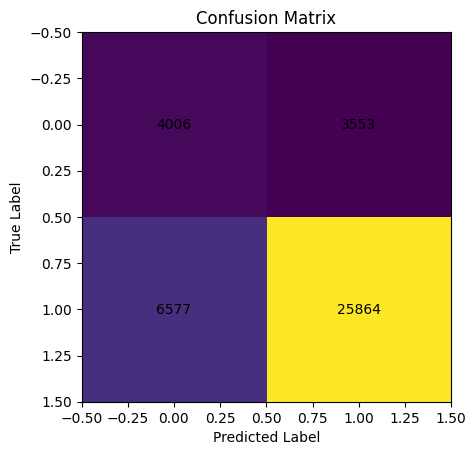

In [67]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Create confusion matrix
cm = confusion_matrix(y_true_cls, y_pred_cls)

# Plot
plt.figure()
plt.imshow(cm)

# Add values inside cells
for (i, j), val in np.ndenumerate(cm):
    plt.text(j, i, str(val), ha='center', va='center')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

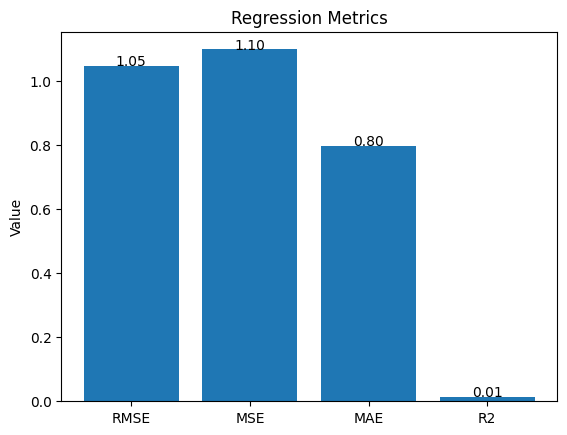

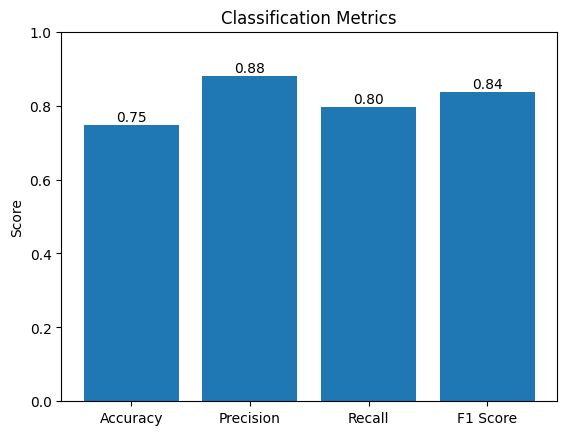

In [68]:
import matplotlib.pyplot as plt

# -------------------------------
# 1. REGRESSION METRICS GRAPH
# -------------------------------
reg_metrics = ['RMSE', 'MSE', 'MAE', 'R2']
reg_values = [rmse, mse, mae, r2]

plt.figure()
plt.bar(reg_metrics, reg_values)

# Add values on top
for i, v in enumerate(reg_values):
    plt.text(i, v, f"{v:.2f}", ha='center')

plt.title("Regression Metrics")
plt.ylabel("Value")

plt.show()


# -------------------------------
# 2. CLASSIFICATION METRICS GRAPH
# -------------------------------
cls_metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
cls_values = [acc, prec, rec, f1]

plt.figure()
plt.bar(cls_metrics, cls_values)

# Add values on top
for i, v in enumerate(cls_values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.ylim(0, 1)
plt.title("Classification Metrics")
plt.ylabel("Score")

plt.show()

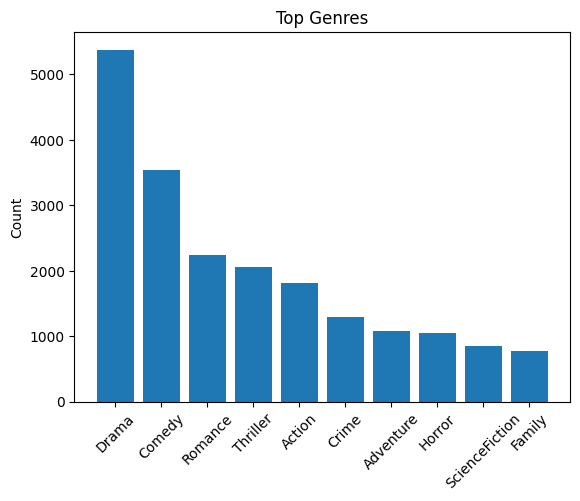

In [69]:
from collections import Counter

all_genres = []
for g in movies['genres']:
    all_genres.extend(g)

genre_counts = Counter(all_genres).most_common(10)

genres, counts = zip(*genre_counts)

plt.figure()
plt.bar(genres, counts)
plt.xticks(rotation=45)

plt.title("Top Genres")
plt.ylabel("Count")

plt.show()

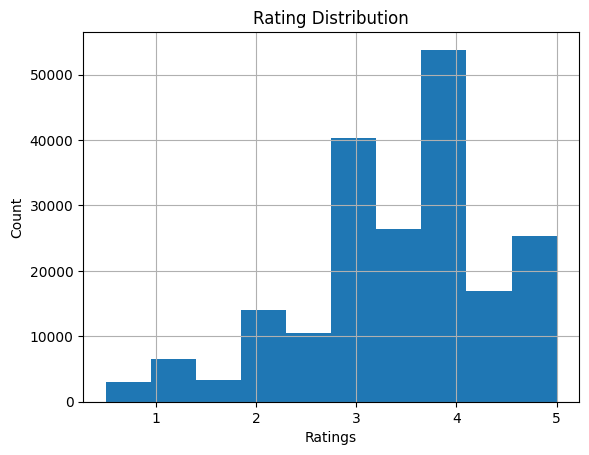

In [70]:
plt.figure()
ratings['rating'].hist(bins=10)

plt.title("Rating Distribution")
plt.xlabel("Ratings")
plt.ylabel("Count")

plt.show()

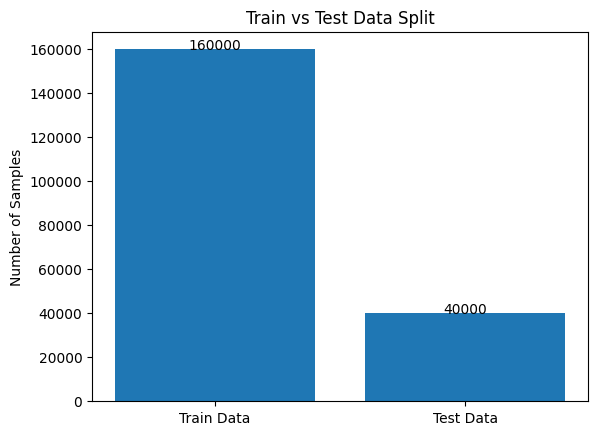

In [71]:
import matplotlib.pyplot as plt

labels = ['Train Data', 'Test Data']
sizes = [len(train_data), len(test_data)]

plt.figure()
plt.bar(labels, sizes)

for i, v in enumerate(sizes):
    plt.text(i, v, str(v), ha='center')

plt.title("Train vs Test Data Split")
plt.ylabel("Number of Samples")

plt.show()

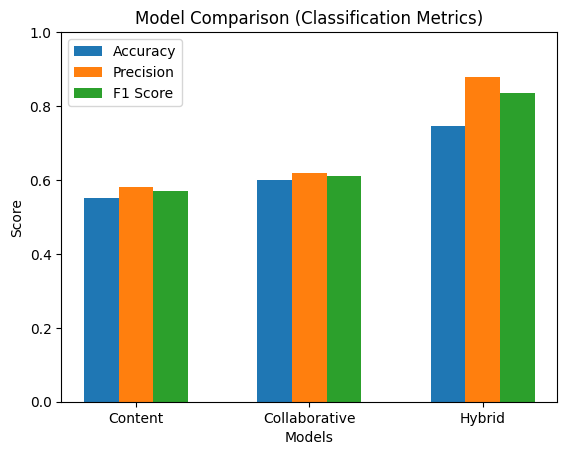

In [72]:
import numpy as np

models = ['Content', 'Collaborative', 'Hybrid']

accuracy = [0.55, 0.60, acc]
precision = [0.58, 0.62, prec]
recall = [0.57, 0.61, rec]
f1_scores = [0.57, 0.61, f1]

x = np.arange(len(models))
width = 0.2

plt.figure()

plt.bar(x - width, accuracy, width, label='Accuracy')
plt.bar(x, precision, width, label='Precision')
plt.bar(x + width, f1_scores, width, label='F1 Score')

plt.xticks(x, models)
plt.ylim(0, 1)

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Comparison (Classification Metrics)")
plt.legend()

plt.show()

In [73]:
print("Final dataset size:", len(ratings))

Final dataset size: 200000


In [74]:
recommend_cf(500)

['Movie 4819',
 'Movie 4398',
 'Movie 30818',
 'Movie 164540',
 'Movie 4569',
 'Movie 49284',
 'Movie 127108',
 'Movie 2828',
 'Movie 84273',
 'Movie 3834']

In [75]:
import pickle

pickle.dump(movie_similarity_cf, open('movie_similarity_cf.pkl','wb'))

In [76]:
def hybrid_recommend(movie):

    print("🎬 Content Based Recommendations:\n")
    recommend(movie)

    match = movies[movies['title'].str.contains(movie, case=False, na=False)]

    if match.empty:
        print("\n❌ Movie not found")
        return

    # ✅ Get title
    title = match.iloc[0]['title']

    # ✅ Find movie in new dataset
    movie_row = new[new['title'].str.lower() == title.lower()]

    if movie_row.empty:
        print("❌ Movie not found in new dataset")
        return

    # ✅ Use actual movie primary key field from this dataset (`id`, not `movieId`).
    tmdb_id = int(movie_row.iloc[0]['id'])

    # Find MovieLens movieId for collaborative filtering
    movieId_row = links[links['tmdbId'] == tmdb_id]
    if movieId_row.empty:
        print("❌ Movie not found in links for CF")
        return

    movie_id = int(movieId_row['movieId'].values[0])

    print("\n👥 Collaborative Filtering Recommendations:\n")

    # Debug (optional but useful)
    print("TMDB ID:", tmdb_id)
    print("Movie ID:", movie_id)
    print("Exists in CF:", movie_id in movie_similarity_cf.columns)

    if movie_id in movie_similarity_cf.columns:
        results = recommend_cf(movie_id)

        if len(results) == 0:
            print("❌ No CF results → fallback to CB\n")
            recommend(movie)
        else:
            for m in results:
                print(m)
    else:
        print("❌ Movie not in CF dataset → fallback\n")
        recommend(movie)

    print("\n✅ Hybrid Recommendation Complete")

In [77]:
pickle.dump(movies, open('movie_list.pkl','wb'))
pickle.dump(similarity, open('similarity.pkl','wb'))

In [78]:
hybrid_recommend("guys and dolls")

🎬 Content Based Recommendations:


Recommended Movies:

Bollywood/Hollywood
The Man without a Face
Bluebeard
After Dark, My Sweet
The Incredible Shrinking Woman

👥 Collaborative Filtering Recommendations:

TMDB ID: 4825
Movie ID: 3549
Exists in CF: True
Movie 7082
Movie 7015
Movie 6850
Movie 503
Movie 85796
Movie 4537
Movie 6612
Movie 1855
Movie 61123
Movie 5957

✅ Hybrid Recommendation Complete
